### Practice Exercise Multiple Linear Regression

In [2]:
from pathlib import Path 
import sys

current_dir = Path.cwd()
project_root = current_dir.parent.absolute()

sys.path.insert(0,str(project_root))

from config import DATASETS_DIR , MLR_P

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# loading the dataset
df = pd.read_csv(MLR_P)
print(f'Shape of the Dataset: {df.shape}\n')

print(f'Missing value in Columns: \n{df.isnull().sum()}\n\n')

print(f'Columns of Dataset: \n{df.dtypes}')
df.head()

Shape of the Dataset: (50, 7)

Missing value in Columns: 
Engine_CC        0
Horsepower       0
Weight_kg        0
Mileage_km       0
Car_Age_years    0
Num_Owners       0
Price_USD        0
dtype: int64


Columns of Dataset: 
Engine_CC        int64
Horsepower       int64
Weight_kg        int64
Mileage_km       int64
Car_Age_years    int64
Num_Owners       int64
Price_USD        int64
dtype: object


,Engine_CC,Horsepower,Weight_kg,Mileage_km,Car_Age_years,Num_Owners,Price_USD
0,1198,82,1050,45000,3,1,12500
1,1497,118,1200,32000,2,1,18200
2,1999,148,1400,78000,5,2,15800
3,2497,175,1600,12000,1,1,32500
4,998,68,900,95000,7,3,6800


#### EDA and Visualizations

##### Correlation Heatmap

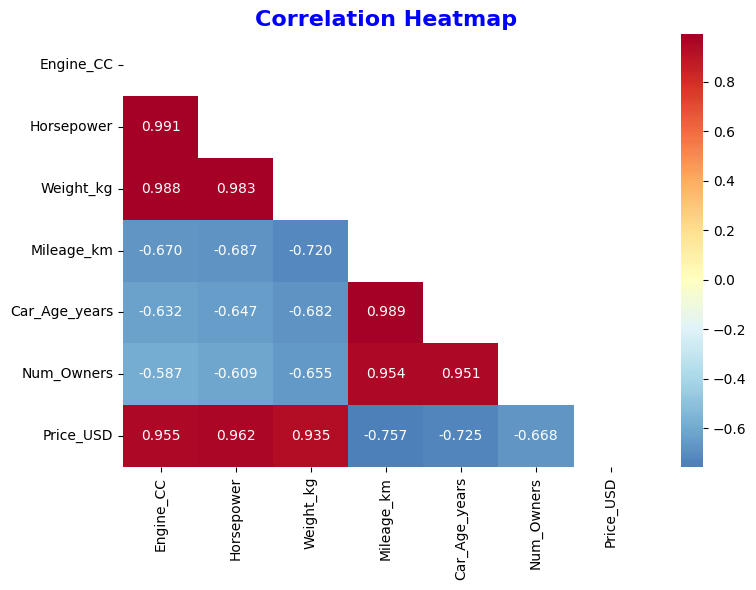

In [5]:
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=True,center=0,fmt='.3f',cmap='RdYlBu_r',mask=mask)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold',color='blue')
plt.tight_layout()
plt.show()

##### Pairplot

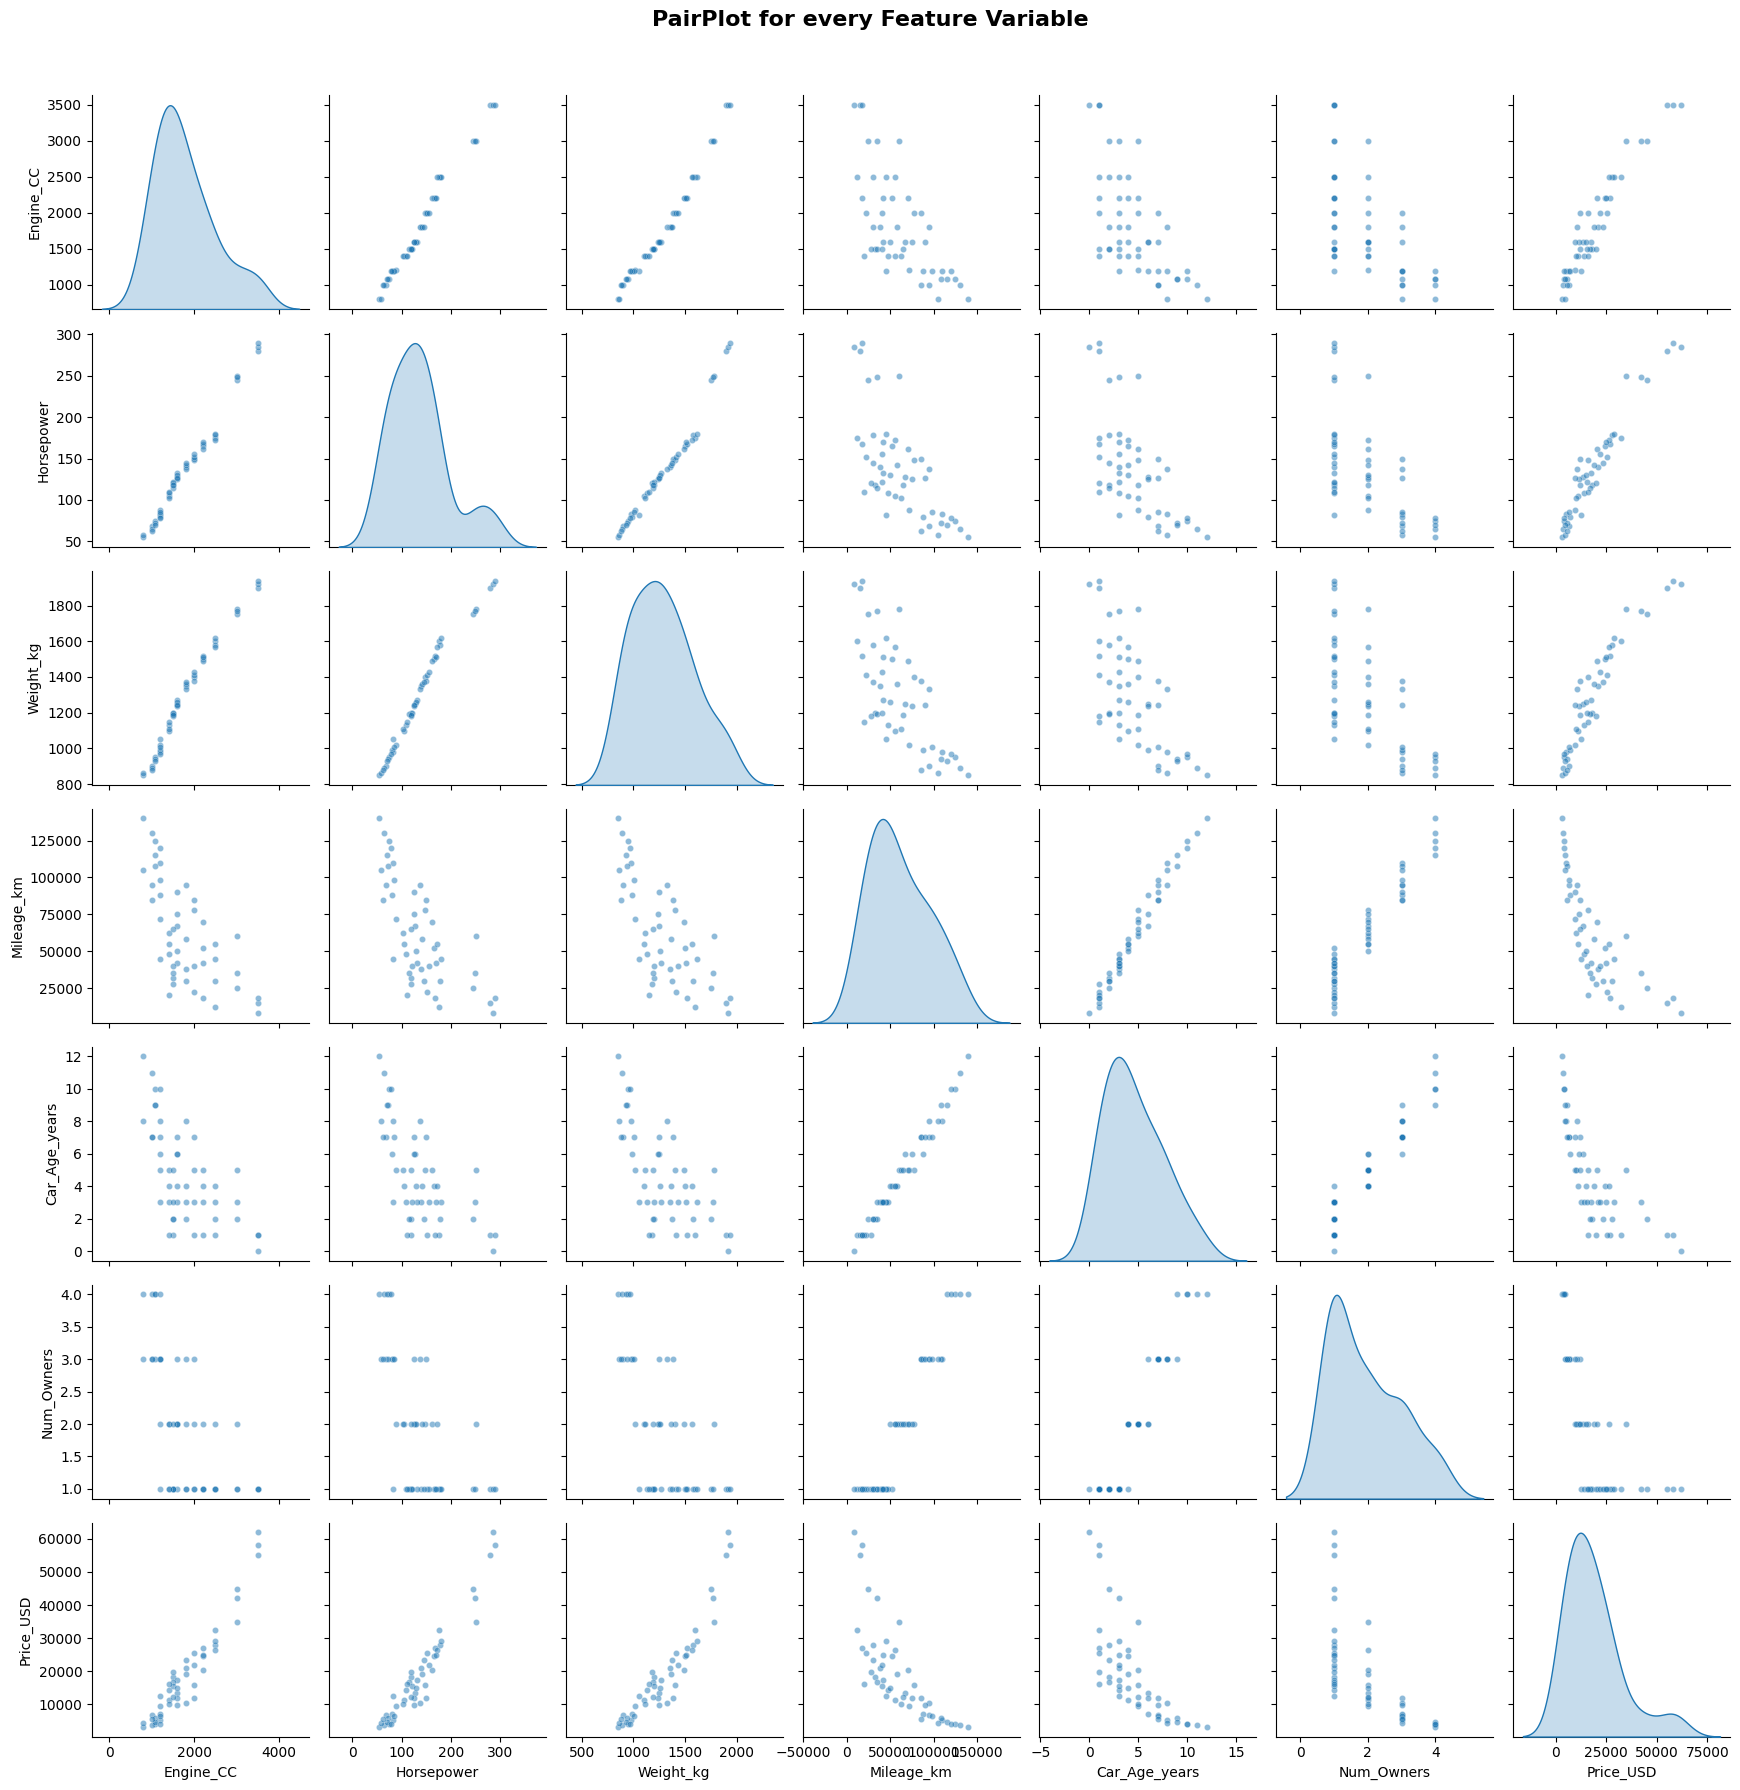

In [6]:
# plt.figure(figsize=(10,6))
sns.pairplot(df, diag_kind='kde',plot_kws={'alpha' : 0.5 , 's': 20})
plt.suptitle('PairPlot for every Feature Variable', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Individual Feature vs Price Scatter Plots

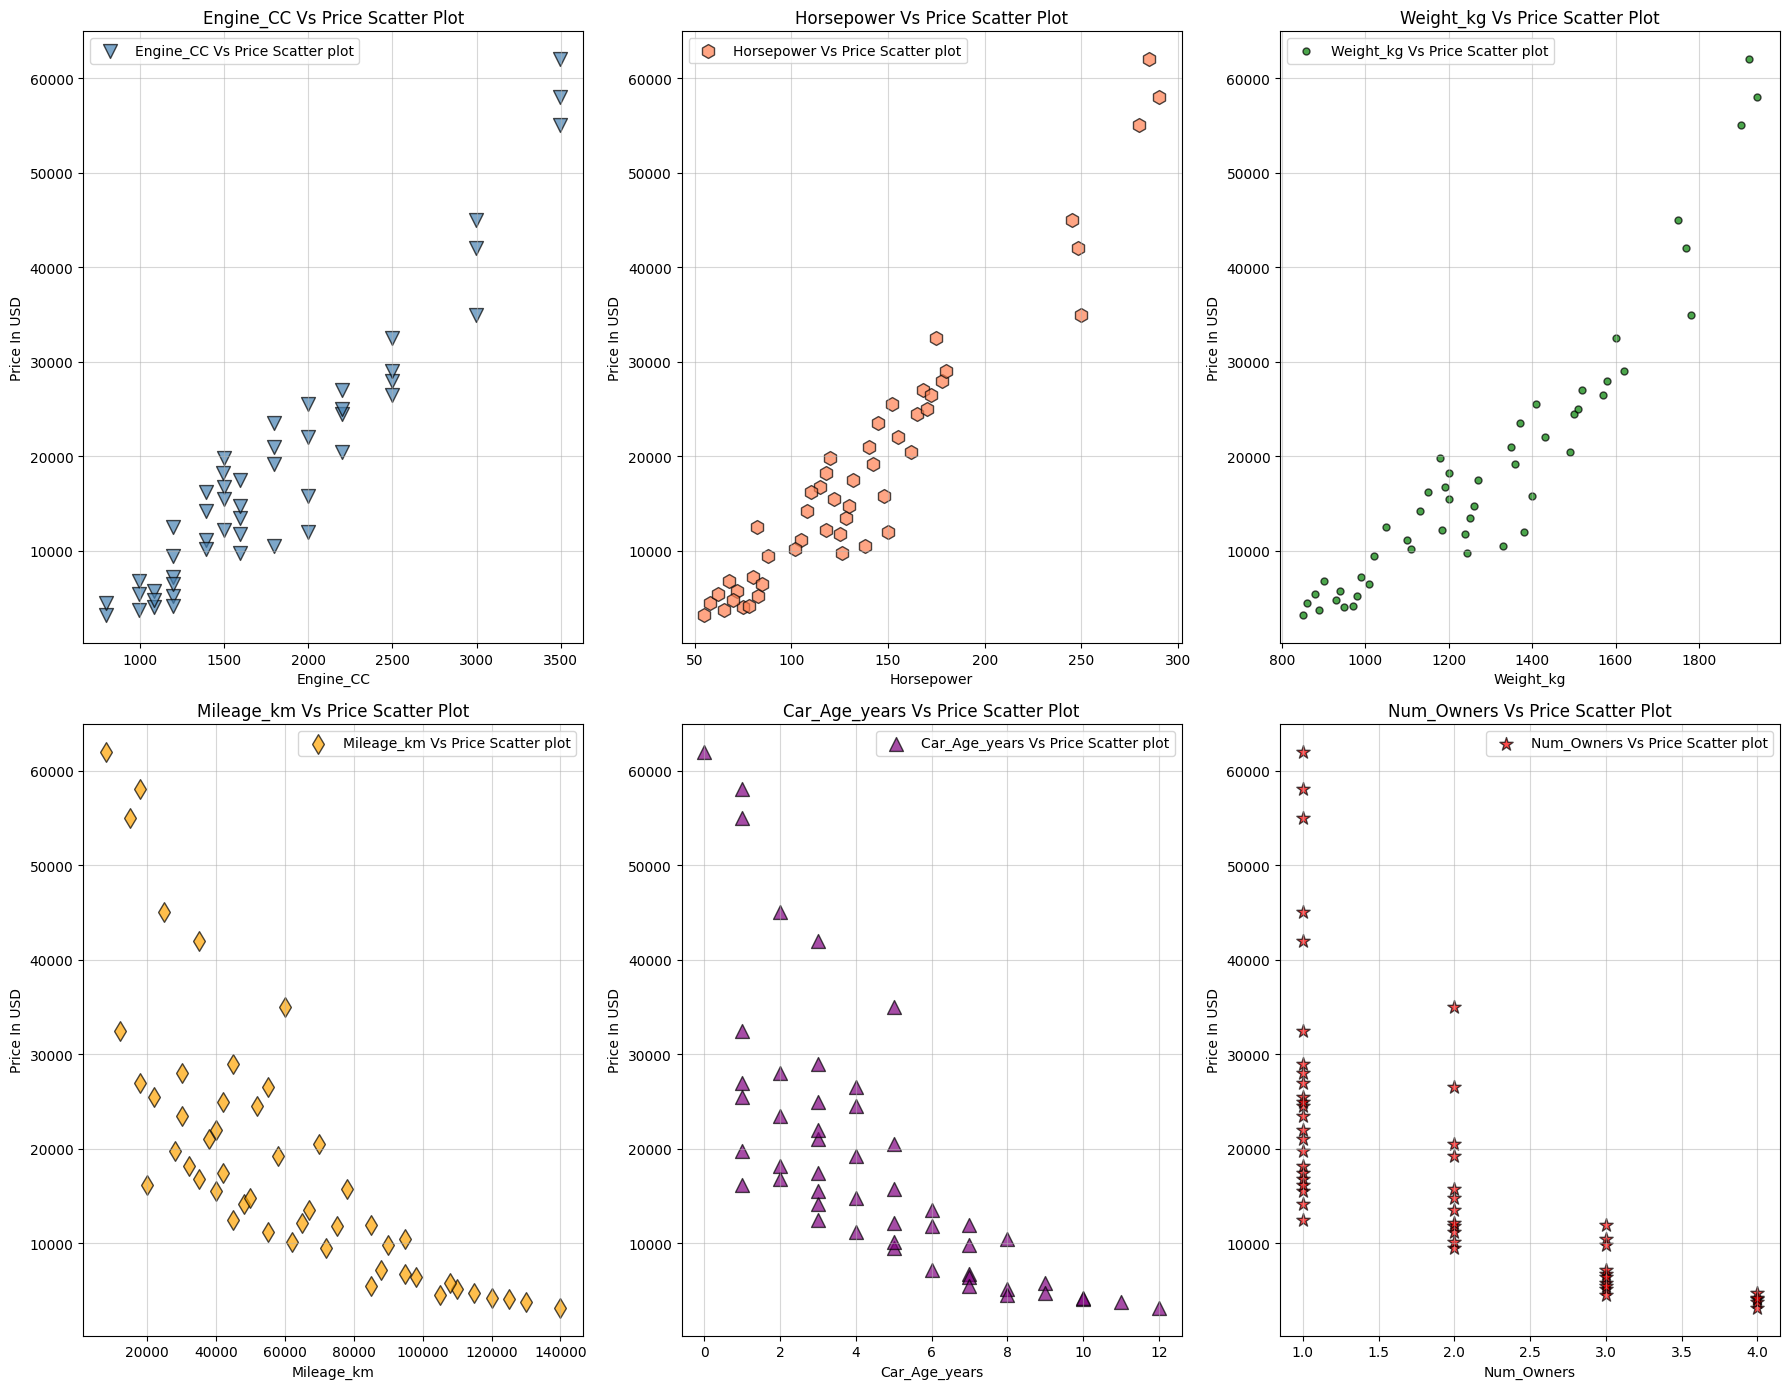

In [7]:
features = ['Engine_CC','Horsepower','Weight_kg','Mileage_km','Car_Age_years','Num_Owners']
colors = ['steelblue', 'coral', 'green', 'orange', 'purple','r']
markers = ['v','h','.','d','^','*']

fig, axes = plt.subplots(2,3,figsize=(18,14))
axes = axes.flatten()
for i, (feat,col) in enumerate(zip(features,colors)):
    axes[i].scatter(df[feat],df['Price_USD'],marker=markers[i],color=colors[i],s=100,label=f"{feat} Vs Price Scatter plot",alpha=0.7, edgecolor='k')
    axes[i].set_ylabel('Price In USD')
    axes[i].set_xlabel(f'{feat}')
    axes[i].set_title(f'{feat} Vs Price Scatter Plot')
    axes[i].grid(True,alpha=0.5)
    axes[i].legend()
plt.tight_layout()
plt.show()

##### Distribution of all features

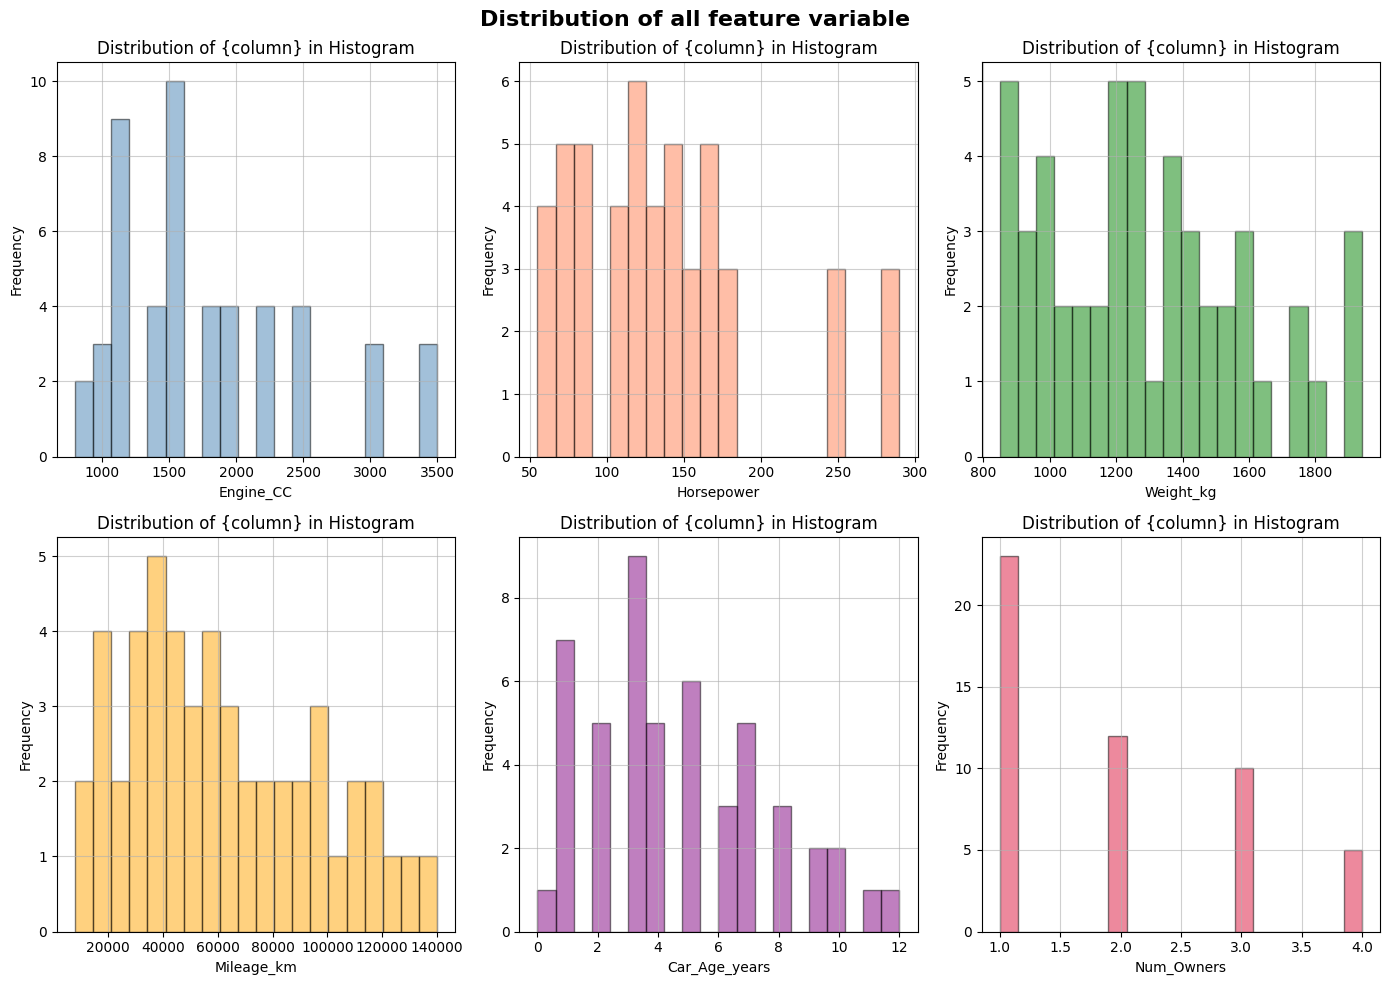

In [8]:
all_cols = features + ['Price_USD']
colors_dist = ['steelblue', 'coral', 'green', 'orange', 'purple', 'crimson']

fig,axes = plt.subplots(2,3,figsize=(14,10))
plt.suptitle('Distribution of all feature variable',fontweight='bold',fontsize=16)
axes = axes.flatten()
for i,(col,column) in enumerate(zip(colors_dist,all_cols)):
    axes[i].hist(df[column],bins=20,color=col,edgecolor='k',alpha=0.5)
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlabel(f'{column}')
    axes[i].set_title('Distribution of {column} in Histogram')
    axes[i].grid(True,alpha=0.6)
plt.tight_layout()
plt.show()

#### Data Preparation

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Price_USD',axis=1)
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#model training
Regressor = LinearRegression()
Regressor.fit(X_train_scaled,y_train)

#making Prediction
y_pred_test = Regressor.predict(X_test_scaled)
y_pred_train = Regressor.predict(X_train_scaled)

print('Coefficient of Every Feature Variable:')
for feat, coef in zip(features,Regressor.coef_):
    print(f'{feat:>20s}: {coef:>12.2f}')


Coefficient of Every Feature Variable:
           Engine_CC:     16739.51
          Horsepower:      7068.62
           Weight_kg:    -15162.60
          Mileage_km:     -4336.70
       Car_Age_years:      1691.67
          Num_Owners:     -1764.80


##### Showing Comparsion between Actual and Predicted variables


In [10]:
comparsion = pd.DataFrame({
    'Engine CC': X_test['Engine_CC'],
    'Actual Price': y_test,
    'Predicted Price': y_pred_test,
    'Difference in Prediction': y_test - y_pred_test,
}).sort_values('Engine CC').reset_index(drop=True)

comparsion

,Engine CC,Actual Price,Predicted Price,Difference in Prediction
0,799,4500,310.602136,4189.397864
1,1086,5800,5528.233533,271.766467
2,1197,6500,6440.717215,59.282785
3,1498,12200,13875.495522,-1675.495522
4,1598,17500,17167.304659,332.695341
5,1999,25500,24109.242387,1390.757613
6,2199,25000,24840.733081,159.266919
7,2496,28000,30859.671591,-2859.671591
8,3498,62000,54298.957838,7701.042162
9,3498,55000,54424.123781,575.876219


##### MODEL EVALUATION METRICS

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#training metrics
R2_score_train = r2_score(y_train, y_pred_train)
MSE_train = mean_squared_error(y_train,y_pred_train)
MAE_train = mean_absolute_error(y_train,y_pred_train)
MSE_train = np.sqrt(MSE_train)

#test Metrics
R2_score_test = r2_score(y_test,y_pred_test)
MSE_test = np.sqrt(mean_squared_error(y_test,y_pred_test))
MAE_test = mean_absolute_error(y_test,y_pred_test)


##### Result Visualizations

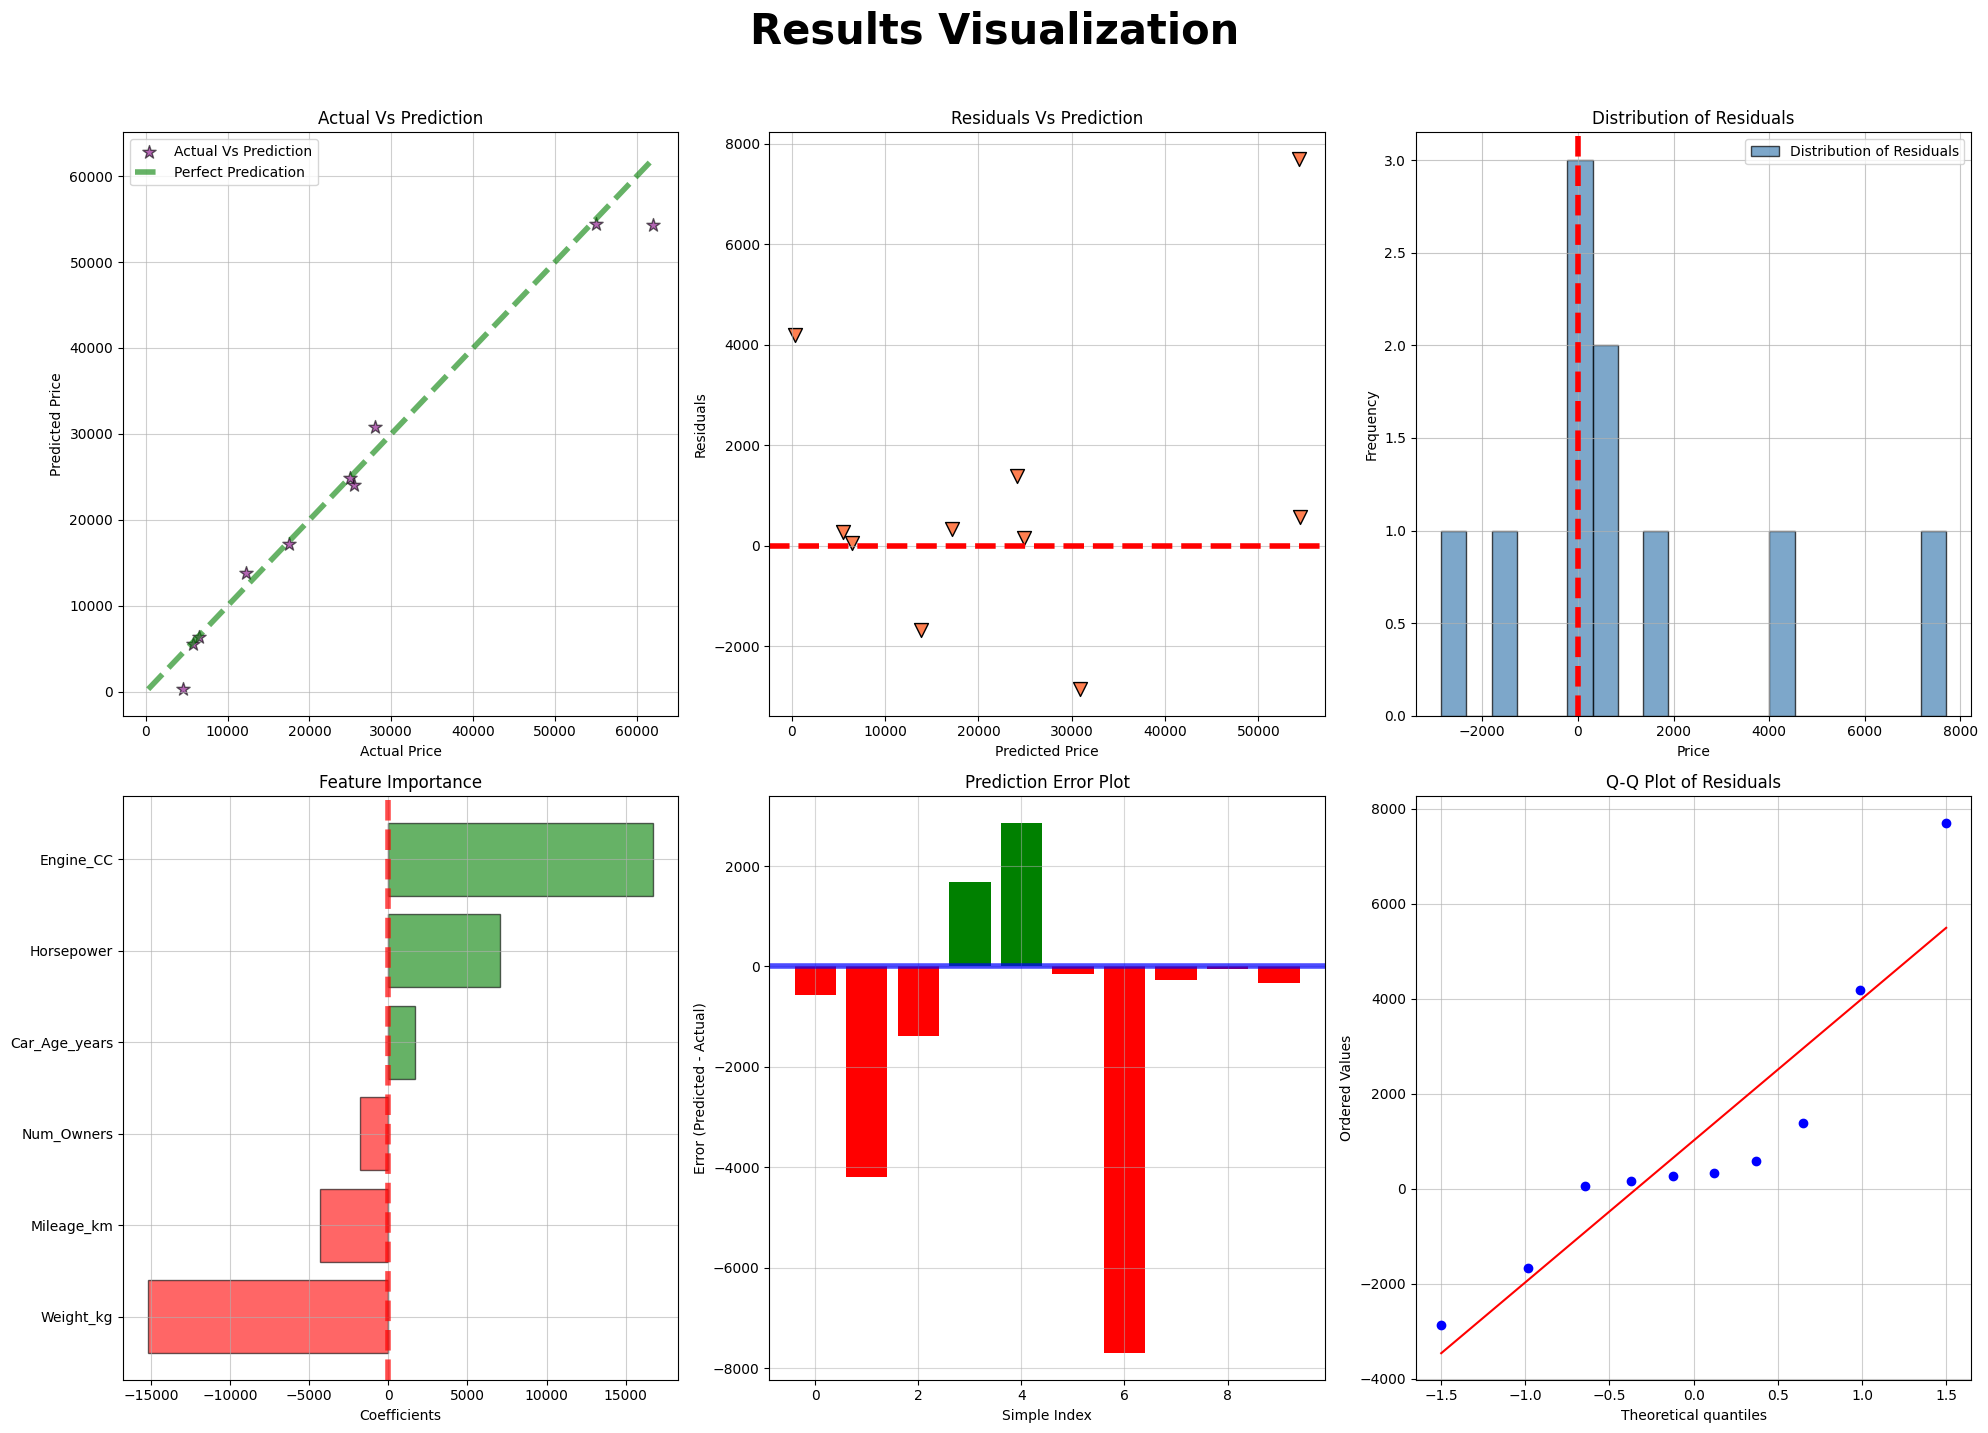

In [37]:
fig, axes = plt.subplots(2,3,figsize=(20,14))
plt.suptitle('Results Visualization',fontsize=30,fontweight='bold',y=1.02)

axes[0,0].scatter(y_test,y_pred_test,marker='*',s=100,color='purple',alpha=0.6,label='Actual Vs Prediction',edgecolor='k')
min_value = min(y_test.min(),y_pred_test.min())
max_value = max(y_test.max(),y_pred_test.max())
axes[0,0].plot([min_value,max_value],[min_value,max_value],lw=4,color='green',linestyle='--',label='Perfect Predication',alpha=0.6)
axes[0,0].set_ylabel('Predicted Price')
axes[0,0].set_xlabel('Actual Price')
axes[0,0].set_title('Actual Vs Prediction')
axes[0,0].grid(True,alpha=0.6)
axes[0,0].legend()

#Residual plot
residuals = y_test.values - y_pred_test
axes[0,1].scatter(y_pred_test,residuals,marker='v',s=100,edgecolor='k',color='coral')
axes[0,1].axhline(y=0,linestyle='--',lw=4,color='r')
axes[0,1].set_xlabel('Predicted Price')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals Vs Prediction')
axes[0,1].grid(True,alpha=0.6)


# plot3 : Residuals Distribution

axes[0,2].hist(residuals,bins=20,color='steelblue',alpha=0.7,edgecolor='k',label='Distribution of Residuals')
axes[0,2].axvline(x=0,color='r',lw=4,linestyle='--')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_xlabel('Price')
axes[0,2].set_title('Distribution of Residuals')
axes[0,2].grid(True,alpha=0.7)
axes[0,2].legend()

# plot4: Feature Importance
df_coff = pd.DataFrame({
    'Features': features,
    'Coefficients': Regressor.coef_
})
df_coff = df_coff.sort_values('Coefficients',ascending=True)
color_bar = ['green' if c > 0 else 'red' for c in df_coff['Coefficients']]

axes[1,0].barh(df_coff['Features'],df_coff['Coefficients'],color=color_bar,edgecolor='k',alpha=0.6)
axes[1,0].axvline(x=0, color='r',alpha=0.7,linestyle='--',lw=4)
axes[1,0].set_xlabel('Coefficients')
axes[1,0].set_title('Feature Importance')
axes[1,0].grid(True,alpha=0.6)

#plot5: Prediction error plot
error = y_pred_test - y_test
axes[1,1].bar(range(len(error)),error, color=['green' if e > 0 else 'red' for e in error])
axes[1,1].axhline(y=0,color='blue',lw=4,alpha=0.7)
axes[1,1].set_ylabel('Error (Predicted - Actual)')
axes[1,1].set_xlabel('Simple Index')
axes[1,1].set_title('Prediction Error Plot')
axes[1,1].grid(True,alpha=0.5)

#plot6: Q-Q plot
import scipy
from scipy import stats
stats.probplot(residuals, dist='norm',plot=axes[1,2])
axes[1,2].set_title('Q-Q Plot of Residuals')
axes[1,2].grid(True,alpha=0.6)


plt.tight_layout()
plt.show()
